
### **Sign Language Recognition - Deep Learning**


Libraries:

In [79]:


import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
import numpy as np
import matplotlib.pyplot as plt
import os

Implementation:

In [97]:
def segmentation(frame, threshold=436):

    global background

    diff = cv2.absdiff(background.astype("uint8"), frame)

    _, processed_frame = cv2.threshold(
        diff,
        threshold,
        255,
        cv2.THRESH_BINARY
    )
    
    contours, _ = cv2.findContours(processed_frame, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None
    else :
        contours = max(contours, key=cv2.contourArea)

    return (processed_frame, contours)

### Generate Dataset

In [101]:
# =========================
# Camera Initialization
# =========================
cam = cv2.VideoCapture(0, cv2.CAP_V4L2)

# =========================
# ROI (Region of Interest)
# =========================
TOP = 50
BOTTOM = 300
RIGHT = 50
LEFT = 250

# =========================
# Global Variables
# =========================
background = None
count = 0
digit = 0
sample_num = 0


# =========================
# Main Loop
# =========================
while True:

    value, frame = cam.read()

    # Copy frame and flip (mirror effect)
    frame_copy = frame.copy()
    frame_copy = cv2.flip(frame_copy, 1)

    # ROI extraction
    roi = frame_copy[TOP:BOTTOM, RIGHT:LEFT]

    # Preprocessing
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_gray = cv2.GaussianBlur(roi_gray, (9, 9), 0)

    # Initialize background
    if background is None:
        background = roi_gray.copy().astype("float")

    # Draw ROI rectangle
    cv2.rectangle(frame_copy, (RIGHT, TOP), (LEFT, BOTTOM), (0, 255, 0), 2)

    

    # Background learning (first 30 frames)
    if count < 30:
        cv2.accumulateWeighted(roi_gray, background, 0.5)
        cv2.putText(frame_copy, "Loading ...", (280, 280), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 2)


    # Hand segmentation
    collection = segmentation(roi_gray)

    if collection is not None:
        roi_processed, contours = collection 
        cv2.drawContours(
                        frame_copy,
                        [contours+(RIGHT, TOP)], # this is for alignment of contours with original frame
                        -1, # draw all contours
                        (0,0,255), 
                        2 
                                    ) 
        cv2.imshow("Processed", roi_processed)
        if k == ord(" "):
            cv2.putText(frame_copy, str(sample_num)+ "Gesture ("+ str(digit)+")", (70, 45), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.imwrite("gesture/train/" + str(digit) + "/" + str(digit) +"-" + str(sample_num) + ".jpg", roi_processed)
            sample_num += 1

    # Show camera
    cv2.putText(frame_copy, "Gesture ("+ str(digit)+")", (60, 350), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.imshow("Camera", frame_copy)
    count += 1

    # Exit with ESC
    k = cv2.waitKey(1)
    if k == 27:
        break
    
    elif k == 13: # Enter key to save the image
        
        digit = (digit + 1) % 11 
        sample_num = 0
        
        

# =========================
# Release Resources
# =========================
cam.release()
cv2.destroyAllWindows()

In [102]:
train_data_path = "gesture/train"

train_data_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(train_data_path,
                                                                                                                                 target_size=(64, 64),
                                                                                                                                 class_mode='categorical',
                                                                                                                                 batch_size=15,
                                                                                                                                 shuffle=True)

images, labels = next(train_data_batches)
print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)

Found 0 images belonging to 11 classes.
Batch shape: (0, 64, 64, 3)
Labels shape: (0, 11)


In [103]:
labels

array([], shape=(0, 11), dtype=float32)

In [104]:
def display(images):
    fig, axex = plt.subplots(1, 15, figsize=(30, 20))
    for image, ax in zip(images, axex):
        image = np.clip(image, 0, 1)
        ax.imshow(image)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

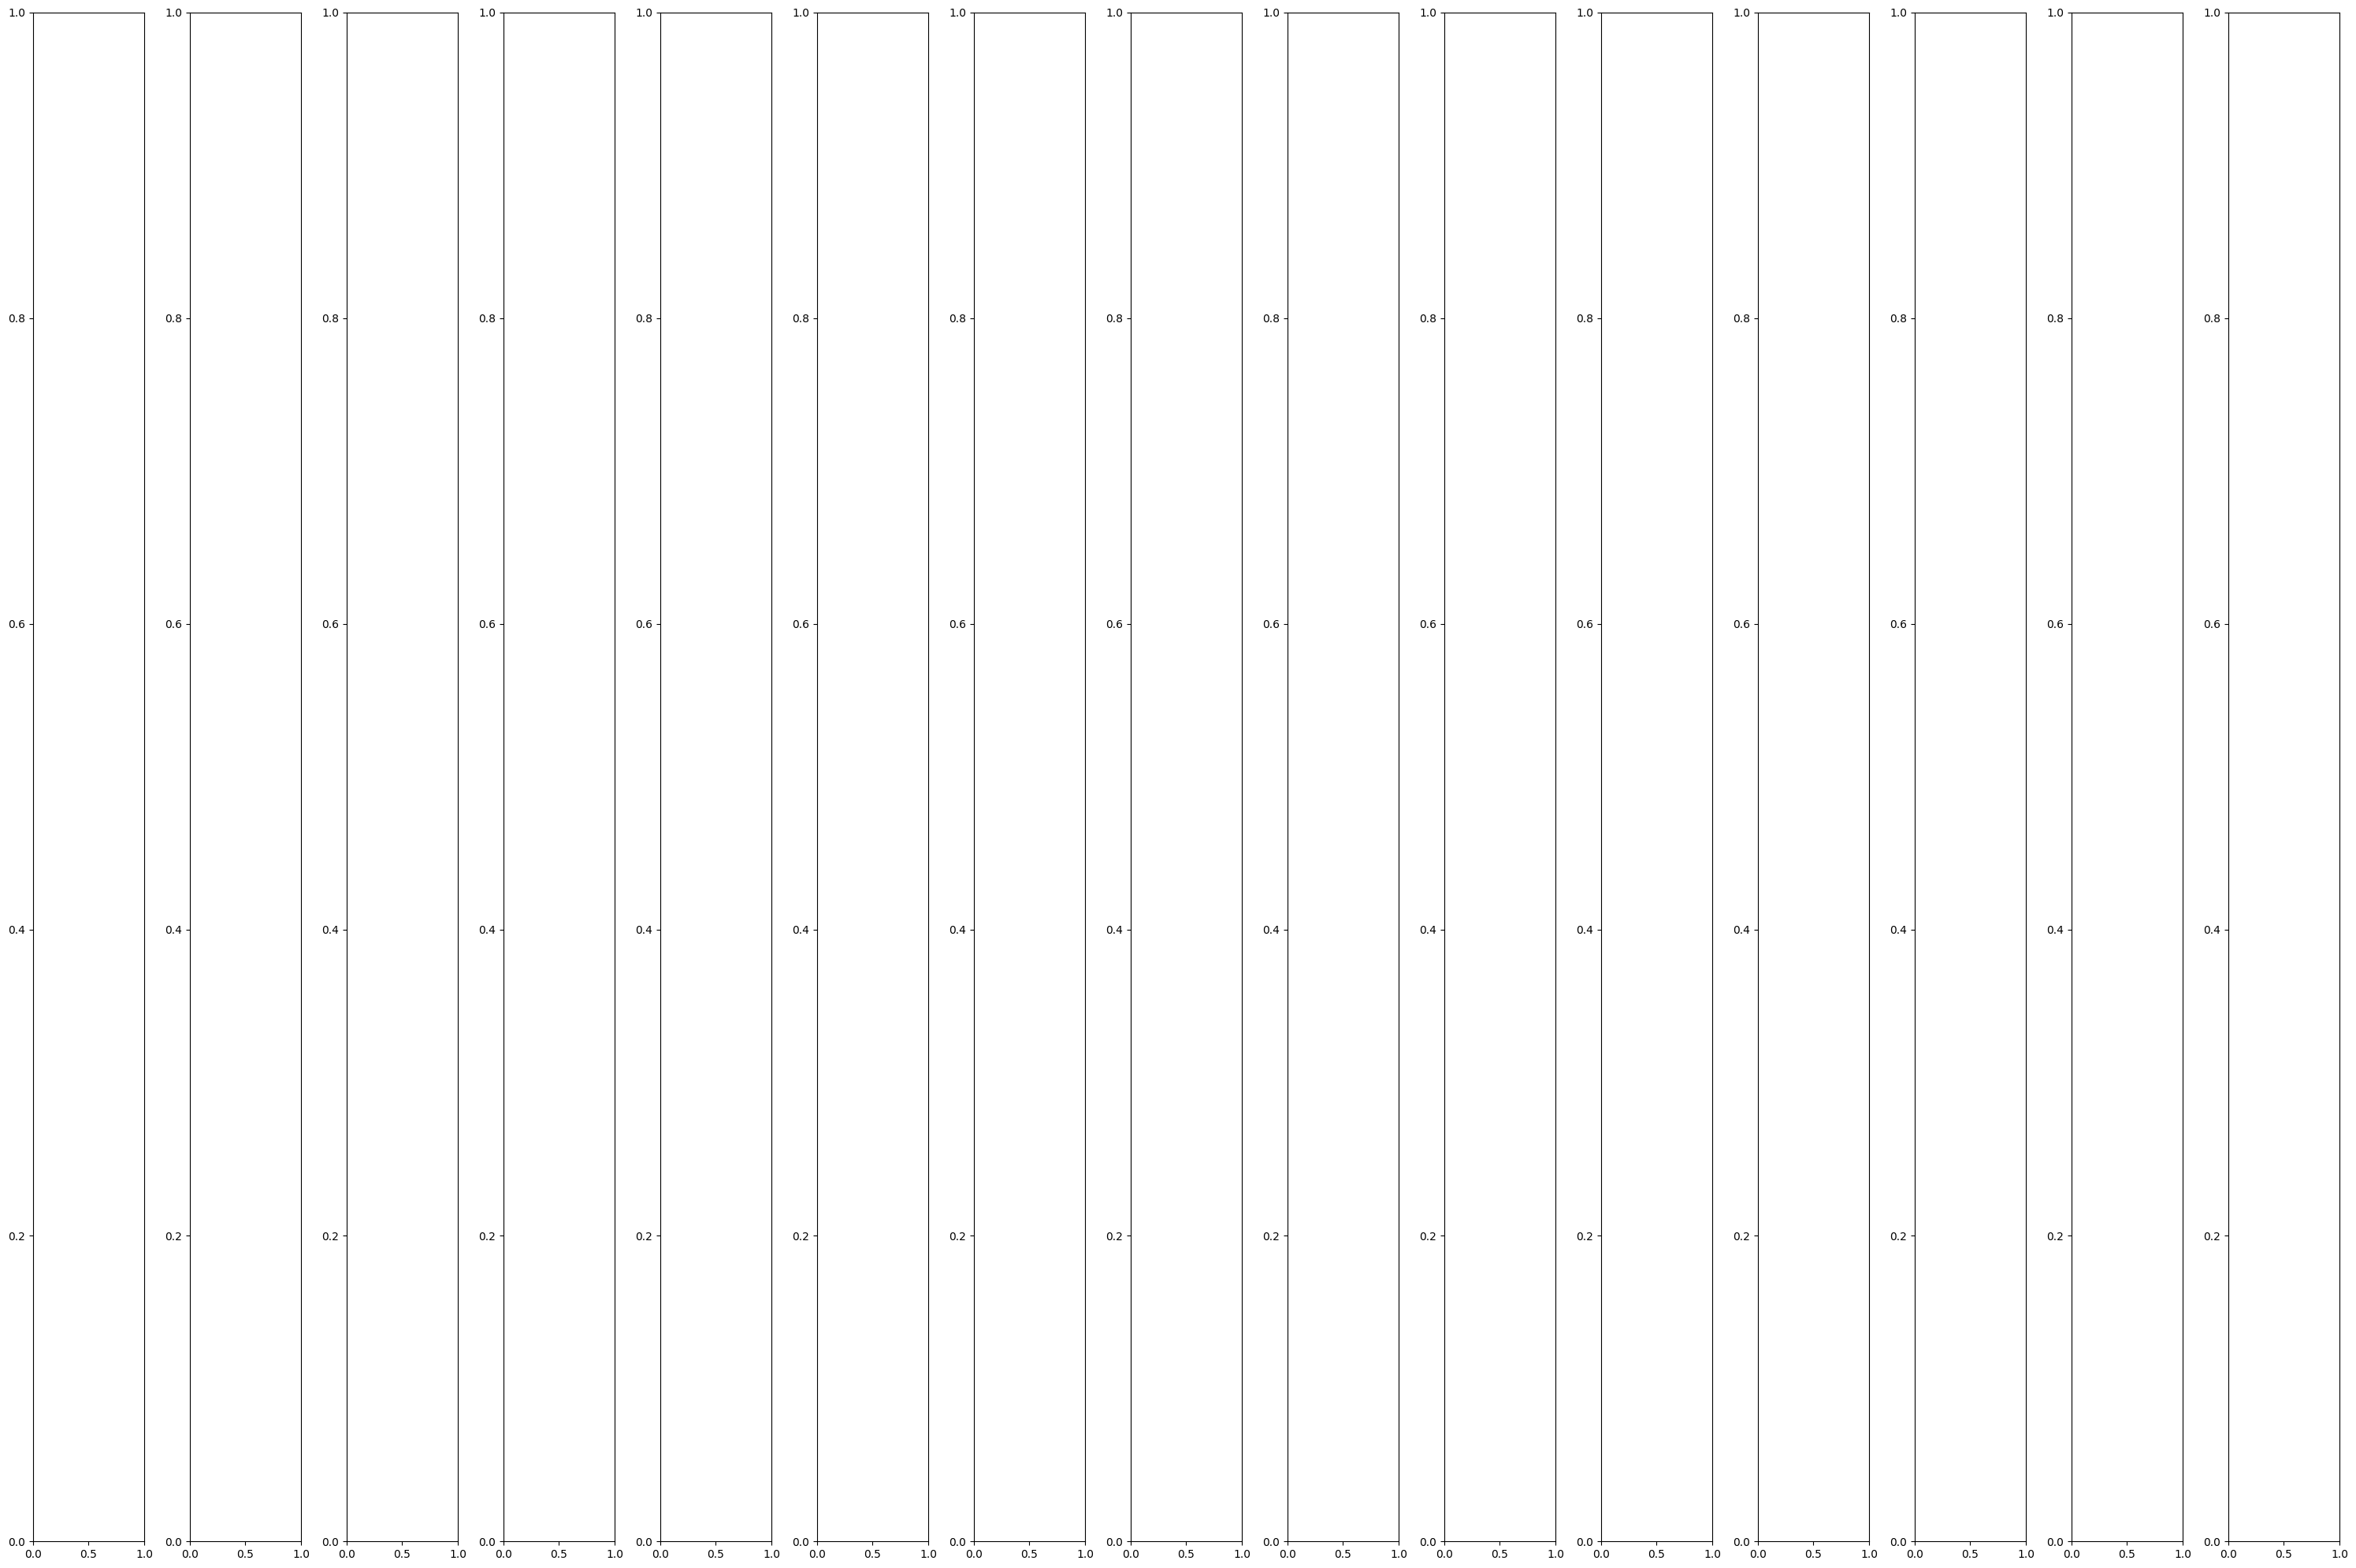

In [105]:
display(images)